# Step 4: Final Optimized Cross-Task Evaluation

This version combines the best approaches:
1. **Architectural Integrity**: Uses explicit model loading with `bicubic` interpolation for positional embeddings
2. **Execution Speed**: Retains the O(1) GPU-vectorized lookup table for COCO-to-Cityscapes class mapping.
3. **Dataset Handling**: Uses the existing `LightningDataModule` for clean data loading.

In [1]:
# @title Install Dependencies
!pip install lightning > /dev/null
!pip install gitignore_parser > /dev/null
!pip install -U 'jsonargparse[signatures]>=4.27.7' >/dev/null

In [2]:
# @title
import os
import sys
import json
import yaml
import torch
import importlib
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from lightning import seed_everything

# 1. Environment Configuration
from google.colab import drive
drive.mount('/content/drive')
project_root = '/content/drive/MyDrive/FundGitHubProject'
eomt_folder = project_root + '/eomt'

os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if eomt_folder not in sys.path:
    sys.path.insert(0, eomt_folder)

from eval.iouEval import iouEval
from eomt.models.vit import ViT
from eomt.models.eomt import EoMT
from eomt.training.mask_classification_semantic import MaskClassificationSemantic
from eomt.training.mask_classification_panoptic import MaskClassificationPanoptic

seed_everything(0, verbose=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")

Mounted at /content/drive
Active Device: cuda


### Loading the Model

**Note on Positional Embedding Interpolation**

Vision Transformer (ViT) positional embeddings are the only resolution-dependent weights within the network. All other tensors (attention, Feed-Forward Networks, and projection weights) operate on 768-dimensional token vectors, independent of the token sequence length. The positional embedding table contains one row per patch position, resulting in a shape of `(1, N, 768)`, where `N = (img_size / patch_size)²`.

For evaluating on the Cityscapes dataset at a 1024px resolution (following the EoMT paper), the model requires `N = 5329` (a 73×73 grid). However, the provided checkpoint was saved with `N = 4096` (a 64×64 grid, corresponding to 896px). To bridge this gap, we resize the embedding table by treating it as a 2D spatial image: we reshape it, permute to a channels-first format, apply bicubic interpolation, and permute it back.

Bicubic interpolation is chosen over bilinear because DINOv2 positional embeddings are inherently smooth across the grid by design, and a cubic kernel better preserves this smoothness during upscaling. This interpolation technique is a standard practice utilized by both the DINOv2 and EoMT authors.

In [3]:
def _load_state_dict_into(model, ckpt_path):
    state = torch.load(ckpt_path, map_location='cpu', weights_only=True)
    if isinstance(state, dict) and 'state_dict' in state:
        state = state['state_dict']
    if not any(k.startswith('network.') for k in state):
        state = {f'network.{k}': v for k, v in state.items()}

    model_sd = model.state_dict()
    for key in list(state.keys()):
        if 'pos_embed' not in key:
            continue
        if key not in model_sd:
            continue
        ckpt_shape  = state[key].shape
        model_shape = model_sd[key].shape
        if ckpt_shape == model_shape:
            continue

        N_ckpt, D   = ckpt_shape[1], ckpt_shape[2]
        N_model     = model_shape[1]
        H_c = W_c   = int(N_ckpt  ** 0.5)
        H_m = W_m   = int(N_model ** 0.5)

        pe = state[key]
        pe = pe.reshape(1, H_c, W_c, D).permute(0, 3, 1, 2)
        pe = F.interpolate(pe.float(), size=(H_m, W_m),
                           mode='bicubic', align_corners=False)
        pe = pe.permute(0, 2, 3, 1).reshape(1, N_model, D)
        state[key] = pe
        print(f'  interpolated {key}: {list(ckpt_shape)} -> {list(model_shape)}')

    model.load_state_dict(state, strict=False)
    print(f'  loaded {ckpt_path}')

    return model

def load_cs_model(ckpt_path, img_size=(1024, 1024)):
    encoder = ViT(img_size=img_size, backbone_name='vit_base_patch14_reg4_dinov2')
    network = EoMT(encoder, num_classes=19, num_q=100, num_blocks=3)
    model = MaskClassificationSemantic(
        network=network, img_size=img_size, num_classes=19, attn_mask_annealing_enabled=False
    )
    return _load_state_dict_into(model, ckpt_path).eval().to(device)

def load_coco_model(ckpt_path, img_size=(640, 640)):
    stuff_classes = list(range(80, 133))
    encoder = ViT(img_size=img_size, backbone_name='vit_base_patch14_reg4_dinov2')
    network = EoMT(encoder, num_classes=133, num_q=200, num_blocks=3)
    model = MaskClassificationPanoptic(
        network=network, img_size=img_size, num_classes=133,
        stuff_classes=stuff_classes, attn_mask_annealing_enabled=False
    )
    return _load_state_dict_into(model, ckpt_path).eval().to(device)

In [4]:
## 3. Instantiate Models and DataModule
from eomt.datasets.cityscapes_semantic import CityscapesSemantic

print('Loading EoMT-Cityscapes...')
model_cs = load_cs_model("eomt/eomt_weights/eomt_cityscapes.bin", img_size=(1024, 1024))

print('\nLoading EoMT-COCO...')
model_coco = load_coco_model("eomt/eomt_weights/eomt_coco.bin", img_size=(640, 640))

dm_cs = CityscapesSemantic(path="eomt/data", batch_size=1, num_workers=2, img_size=(1024, 1024))
dm_cs.setup("validate")

Loading EoMT-Cityscapes...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


  loaded eomt/eomt_weights/eomt_cityscapes.bin

Loading EoMT-COCO...
  loaded eomt/eomt_weights/eomt_coco.bin


In [5]:
## 4 COCO Zero-Shot Evaluation
mapping_path = os.path.join(project_root, 'coco-classes-mapping-master/coco_to_cs.json')
with open(mapping_path, 'r') as f:
    numerical_map = json.load(f)

lookup_table = torch.full((256,), 19, dtype=torch.long, device=device)
for model_idx_str, cs_id in numerical_map.items():
    lookup_table[int(model_idx_str)] = cs_id

evaluator = iouEval(20)

for batch in tqdm(dm_cs.val_dataloader(), desc="Evaluating Mapped COCO"):
    imgs, targets = batch
    gt = model_cs.to_per_pixel_targets_semantic(targets, 19)[0].to(device)

    with torch.no_grad():
        tx = model_coco.resize_and_pad_imgs_instance_panoptic([imgs[0].to(device)])
        mp, cp = model_coco(tx)
        mp = model_coco.revert_resize_and_pad_logits_instance_panoptic(
            F.interpolate(mp[-1], model_coco.img_size, mode="bilinear"),
            [imgs[0].shape[-2:]]
        )
        pred = model_coco.to_per_pixel_preds_panoptic(
            mp, cp[-1], model_coco.stuff_classes, 0.8, 0.8
        )[0][..., 0]

        mapped_pred = lookup_table[pred.long()]
        evaluator.addBatch(mapped_pred.unsqueeze(0).unsqueeze(0), gt.unsqueeze(0).unsqueeze(0))

_, ious = evaluator.getIoU()
print(f"\nUpdated Zero-Shot COCO mIoU on Cityscapes: {ious[:19].mean()*100:.2f}%")

Evaluating Mapped COCO: 100%|██████████| 500/500 [04:08<00:00,  2.01it/s]


Updated Zero-Shot COCO mIoU on Cityscapes: 48.82%


In [6]:
## 5. Supervised Evaluation (Cityscapes)

evaluator_cs = iouEval(20)

for batch in tqdm(dm_cs.val_dataloader(), desc="Evaluating Cityscapes Model"):
    imgs, targets = batch
    gt = model_cs.to_per_pixel_targets_semantic(targets, 19)[0].to(device)

    with torch.no_grad():
        crops, origins = model_cs.window_imgs_semantic([imgs[0].to(device)])
        m_l, c_l = model_cs(crops)
        m_l = F.interpolate(m_l[-1], model_cs.img_size, mode="bilinear")
        crop_logits = model_cs.to_per_pixel_logits_semantic(m_l, c_l[-1])
        pred_cs = model_cs.revert_window_logits_semantic(crop_logits, origins, [imgs[0].shape[-2:]])[0].argmax(0)

        evaluator_cs.addBatch(pred_cs.unsqueeze(0).unsqueeze(0), gt.unsqueeze(0).unsqueeze(0))

_, ious_cs = evaluator_cs.getIoU()
print(f"\nCityscapes Supervised mIoU: {ious_cs[:19].mean()*100:.2f}%")

Evaluating Cityscapes Model: 100%|██████████| 500/500 [12:44<00:00,  1.53s/it]


Cityscapes Supervised mIoU: 81.68%


### Visualization routines:

Generating Class-wise mIoU Histogram...


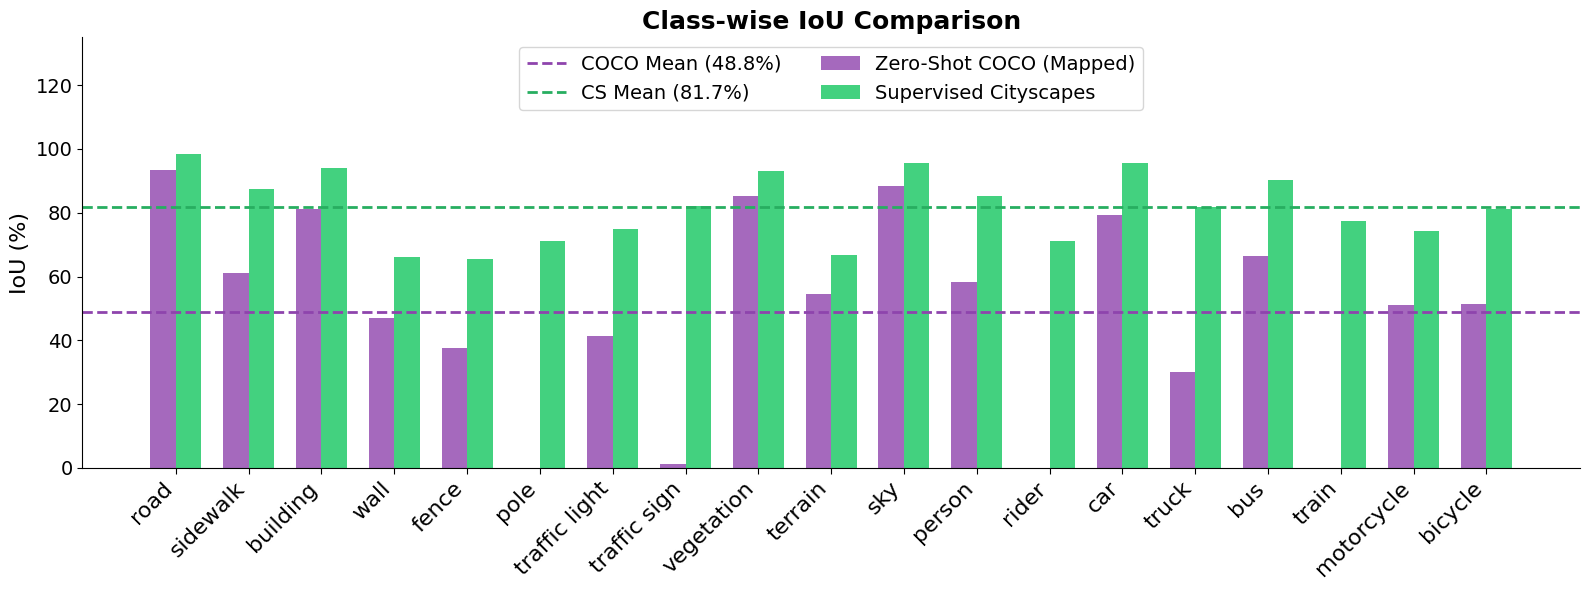

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

CS_CLASS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic light",
    "traffic sign", "vegetation", "terrain", "sky", "person", "rider", "car",
    "truck", "bus", "train", "motorcycle", "bicycle"
]

# ==========================================
# TASK 1: Class-wise mIoU Histogram
# ==========================================
print("Generating Class-wise mIoU Histogram...")
save_dir = os.path.join(project_root, 'saved_visualizations')
os.makedirs(save_dir, exist_ok=True)

if 'ious' in globals() and 'ious_cs' in globals():
    coco_miou = ious[:19].cpu().numpy() * 100
    cs_miou = ious_cs[:19].cpu().numpy() * 100

    fig_miou, ax_miou = plt.subplots(figsize=(16, 6))
    x = np.arange(19)
    width = 0.35

    ax_miou.bar(x - width/2, coco_miou, width, label='Zero-Shot COCO (Mapped)', color='#9b59b6', alpha=0.9)
    ax_miou.bar(x + width/2, cs_miou, width, label='Supervised Cityscapes', color='#2ecc71', alpha=0.9)

    # Add dashed lines for mean mIoU
    mean_coco = coco_miou.mean()
    mean_cs = cs_miou.mean()
    ax_miou.axhline(mean_coco, color='#8e44ad', linestyle='--', linewidth=2, label=f'COCO Mean ({mean_coco:.1f}%)')
    ax_miou.axhline(mean_cs, color='#27ae60', linestyle='--', linewidth=2, label=f'CS Mean ({mean_cs:.1f}%)')

    ax_miou.set_xticks(x)
    ax_miou.set_xticklabels(CS_CLASS_NAMES, rotation=45, ha='right', fontsize=16)
    ax_miou.set_ylabel('IoU (%)', fontsize=16)
    ax_miou.set_title('Class-wise IoU Comparison', fontsize=18, fontweight='bold')
    ax_miou.tick_params(axis='y', labelsize=14)

    # Increase y-limit to provide more headroom and prevent legend overlap with bars
    ax_miou.set_ylim(0, 135)

    # Move legend inside to save space and increase font size, using multiple columns
    ax_miou.legend(fontsize=14, loc='upper center', ncol=2)

    # Clean up grid and display mostly y-axis
    ax_miou.grid(False)
    ax_miou.spines['top'].set_visible(False)
    ax_miou.spines['right'].set_visible(False)
    ax_miou.spines['bottom'].set_visible(True)  # Restore x-axis line
    ax_miou.tick_params(axis='x', length=4)      # Restore x tick marks

    plt.tight_layout()
    hist_save_path = os.path.join(save_dir, 'class_miou_histogram.png')
    plt.savefig(hist_save_path, dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("mIoU tensors not found in memory. Please ensure the evaluation cells were run successfully.")


Fetching 5 samples for visualization...
Generating separated prediction plots...


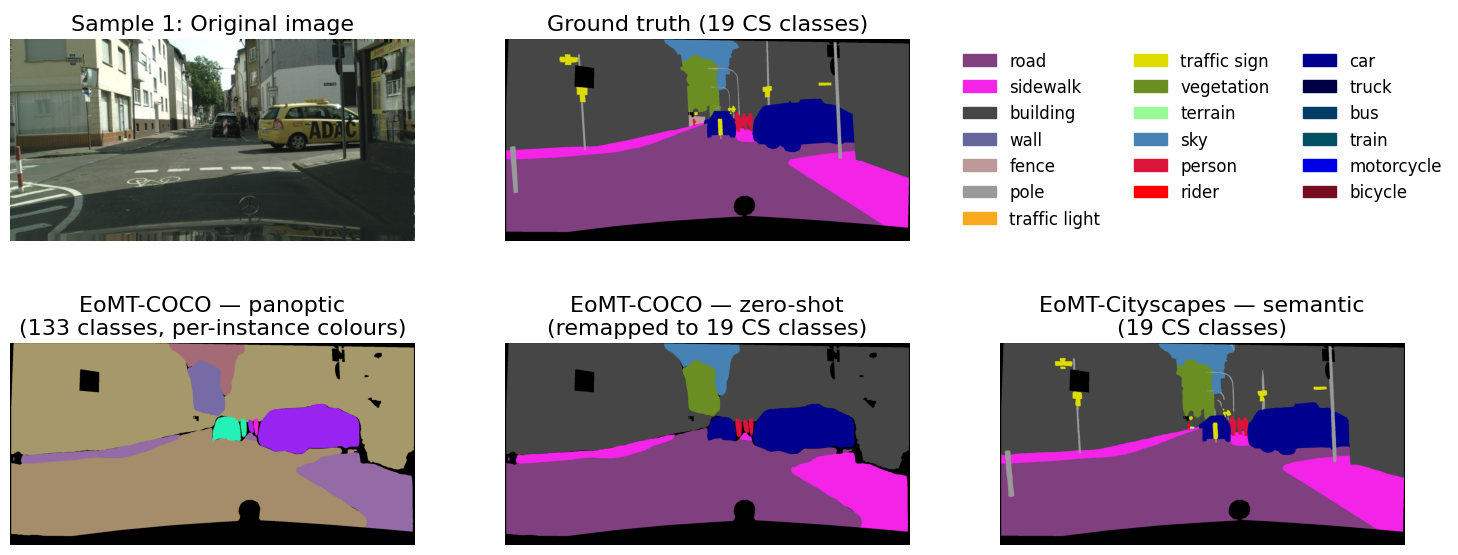

  saved → /content/drive/MyDrive/FundGitHubProject/saved_visualizations/prediction_sample_1.png


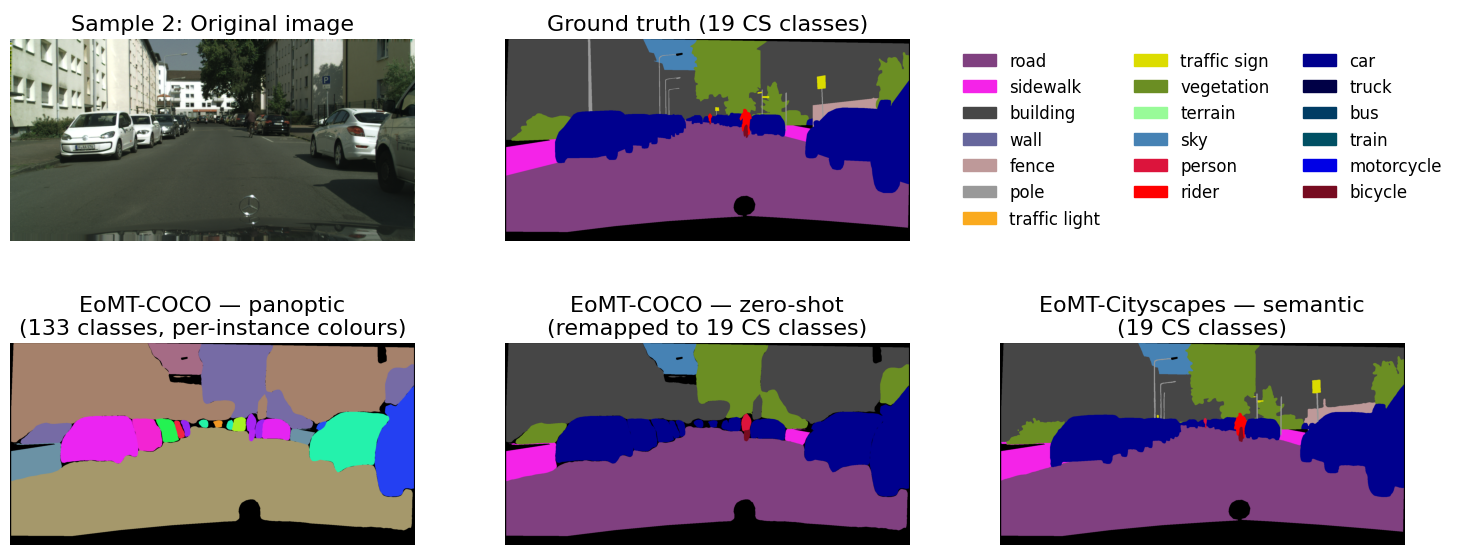

  saved → /content/drive/MyDrive/FundGitHubProject/saved_visualizations/prediction_sample_2.png


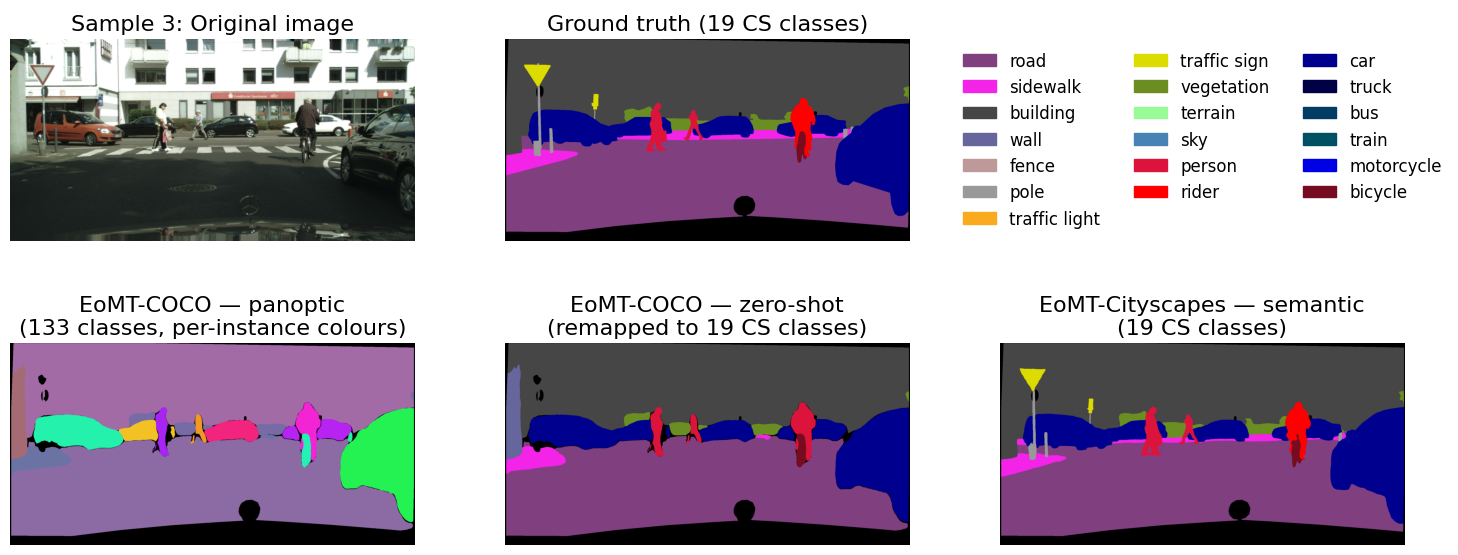

  saved → /content/drive/MyDrive/FundGitHubProject/saved_visualizations/prediction_sample_3.png


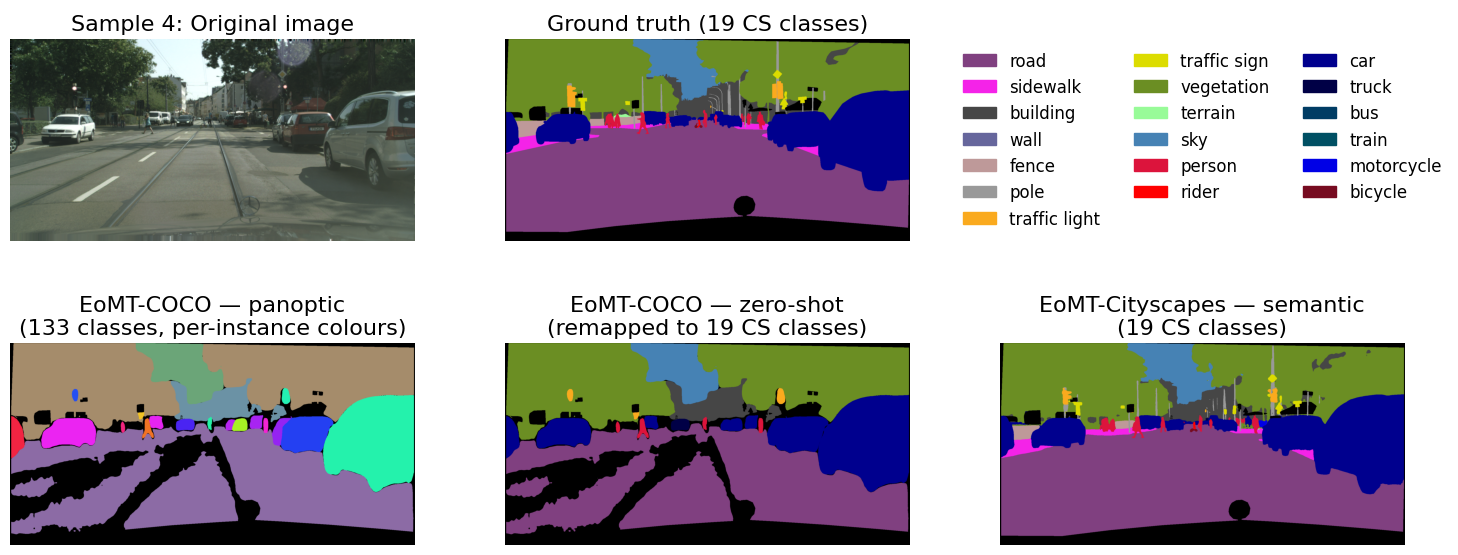

  saved → /content/drive/MyDrive/FundGitHubProject/saved_visualizations/prediction_sample_4.png


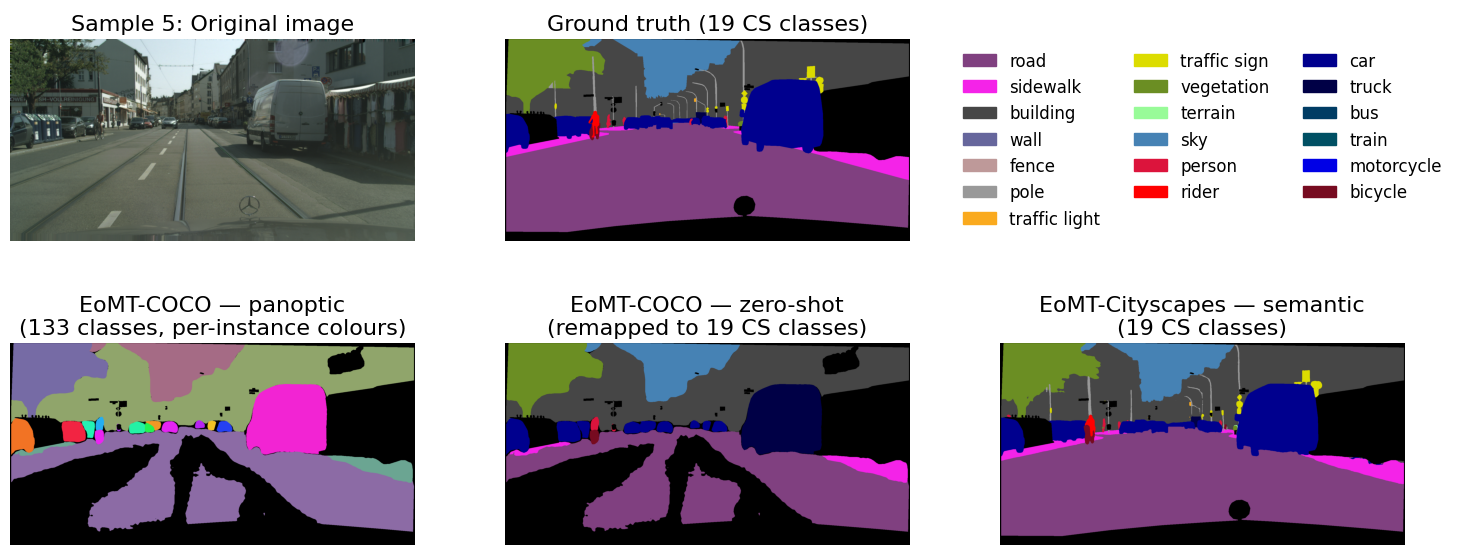

  saved → /content/drive/MyDrive/FundGitHubProject/saved_visualizations/prediction_sample_5.png

Done. Visualizations saved to: /content/drive/MyDrive/FundGitHubProject/saved_visualizations


In [14]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os


## 4 COCO Zero-Shot Evaluation
mapping_path = os.path.join(project_root, 'coco-classes-mapping-master/coco_to_cs.json')
with open(mapping_path, 'r') as f:
    numerical_map = json.load(f)

lookup_table = torch.full((256,), 19, dtype=torch.long, device=device)
for model_idx_str, cs_id in numerical_map.items():
    lookup_table[int(model_idx_str)] = cs_id


# Standard Cityscapes color palette (19 classes + 1 ignore/black)
CS_COLORS = np.array([
    [128, 64, 128], [244, 35, 232], [70, 70, 70], [102, 102, 156],
    [190, 153, 153], [153, 153, 153], [250, 170, 30], [220, 220, 0],
    [107, 142, 35], [152, 251, 152], [70, 130, 180], [220, 20, 60],
    [255, 0, 0], [0, 0, 142], [0, 0, 70], [0, 60, 100],
    [0, 80, 100], [0, 0, 230], [119, 11, 32], [0, 0, 0]
], dtype=np.uint8)

CS_CLASS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic light",
    "traffic sign", "vegetation", "terrain", "sky", "person", "rider", "car",
    "truck", "bus", "train", "motorcycle", "bicycle"
]

COCO_STUFF_CLASSES = set(model_coco.stuff_classes)  # contiguous IDs 80–132


def colorize(mask):
    mask = mask.cpu().numpy().copy()
    mask[mask == 255] = 19   # ignore → black
    mask = np.clip(mask, 0, 19).astype(np.uint8)
    return CS_COLORS[mask]


def colorize_panoptic(class_map, segment_map):
    """Colour a panoptic map so each segment gets a distinct colour.
    Things -> vivid colours; stuff -> muted colours; void -> black."""
    rgb = np.zeros((*segment_map.shape, 3), dtype=np.uint8)
    rng = np.random.default_rng(seed=42)                 # reproducible colours
    for sid in np.unique(segment_map):
        if sid < 0:                                      # void
            continue
        seg = segment_map == sid
        # Representative COCO class of this segment (majority vote).
        coco_cls = int(np.bincount(class_map[seg].astype(int)).argmax())
        is_stuff = coco_cls in COCO_STUFF_CLASSES
        sat, val = (0.35, 0.65) if is_stuff else (0.85, 0.95)
        r, g, b = mcolors.hsv_to_rgb([rng.uniform(0, 1), sat, val])
        rgb[seg] = [int(r * 255), int(g * 255), int(b * 255)]
    return rgb


print("\nFetching 5 samples for visualization...")
val_loader_iter = iter(dm_cs.val_dataloader())
samples = []
for _ in range(5):
    try:
        samples.append(next(val_loader_iter))
    except StopIteration:
        break

save_dir = os.path.join(project_root, 'saved_visualizations')
os.makedirs(save_dir, exist_ok=True)

print("Generating separated prediction plots...")
for row_idx, batch in enumerate(samples):
    imgs, targets = batch
    img_tensor = imgs[0].to(device)
    gt = model_cs.to_per_pixel_targets_semantic(targets, 19)[0].to(device)

    with torch.no_grad():
        # --- COCO model ---
        tx = model_coco.resize_and_pad_imgs_instance_panoptic([img_tensor])
        mp, cp = model_coco(tx)
        mp = model_coco.revert_resize_and_pad_logits_instance_panoptic(
            F.interpolate(mp[-1], model_coco.img_size, mode="bilinear"),
            [img_tensor.shape[-2:]]
        )
        # Keep both channels: [..., 0] = class, [..., 1] = segment/instance ID
        panoptic_pred_coco = model_coco.to_per_pixel_preds_panoptic(
            mp, cp[-1], model_coco.stuff_classes, 0.8, 0.8
        )[0]
        # Semantic channel only, remapped to Cityscapes
        mapped_pred = lookup_table[panoptic_pred_coco[..., 0].long()]

        # --- Cityscapes model ---
        crops, origins = model_cs.window_imgs_semantic([img_tensor])
        m_l, c_l = model_cs(crops)
        m_l = F.interpolate(m_l[-1], model_cs.img_size, mode="bilinear")
        crop_logits = model_cs.to_per_pixel_logits_semantic(m_l, c_l[-1])
        pred_cs = model_cs.revert_window_logits_semantic(
            crop_logits, origins, [img_tensor.shape[-2:]]
        )[0].argmax(0)

        # FIX: The target generator uses 19 as the ignore/void index, not 255.
        # Force predictions to ignore (19) where the ground truth is void.
        ignore_mask = (gt == 19) | (gt == 255)
        mapped_pred[ignore_mask] = 19
        pred_cs[ignore_mask] = 19
        panoptic_pred_coco[ignore_mask, 1] = -1  # Set segment ID to -1 (void) for panoptic map

    fig, axes = plt.subplots(2, 3, figsize=(15, 6))

    axes[0,0].imshow(img_tensor.permute(1, 2, 0).cpu().numpy())
    axes[0,0].set_title(f"Sample {row_idx + 1}: Original image", fontsize=16)
    axes[0,0].axis('off')

    axes[0,1].imshow(colorize(gt))
    axes[0,1].set_title("Ground truth (19 CS classes)", fontsize=16)
    axes[0,1].axis('off')

    # Hide the empty upper right subplot and add legend
    axes[0,2].axis('off')
    legend_patches = [mpatches.Patch(color=CS_COLORS[i]/255.0, label=CS_CLASS_NAMES[i]) for i in range(len(CS_CLASS_NAMES))]
    axes[0,2].legend(handles=legend_patches, loc='center', ncol=3, fontsize=12, frameon=False)

    # Proper panoptic visualisation: each instance gets its own colour
    pan_np = panoptic_pred_coco.cpu().numpy()
    axes[1,0].imshow(colorize_panoptic(pan_np[..., 0], pan_np[..., 1]))
    axes[1,0].set_title("EoMT-COCO — panoptic\n(133 classes, per-instance colours)", fontsize=16)
    axes[1,0].axis('off')

    # Remapped to Cityscapes space for fair comparison
    axes[1,1].imshow(colorize(mapped_pred))
    axes[1,1].set_title("EoMT-COCO — zero-shot\n(remapped to 19 CS classes)", fontsize=16)
    axes[1,1].axis('off')

    axes[1,2].imshow(colorize(pred_cs))
    axes[1,2].set_title("EoMT-Cityscapes — semantic\n(19 CS classes)", fontsize=16)
    axes[1,2].axis('off')

    plt.tight_layout()

    save_path = os.path.join(save_dir, f'prediction_sample_{row_idx + 1}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  saved → {save_path}")

print(f"\nDone. Visualizations saved to: {save_dir}")

In [15]:
import os

project_root = '/content/drive/MyDrive/FundGitHubProject'
os.chdir(project_root)

# 1. Tell Git who you are (required for committing)
!git config --global user.email "colab-user@example.com"
!git config --global user.name "Colab User"

print("--- Staging and Committing ---")
# 2. Stage the specific files
!git add Step4.ipynb
!git add saved_visualizations/

# 3. Create the commit
!git commit -m "Update prediction masking logic and improve visualization charts in Step 4"

print("\n--- Pushing to GitHub ---")
# 4. Push directly (your git remote already has a token configured)
!git push

--- Current Git Status ---
On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   Step4.ipynb

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	deleted:    FundGitHubProject
	modified:   Step4.ipynb
	modified:   Step5.ipynb
	modified:   eomt/checkpoint_utils.py
	deleted:    eomt/configs/README_AI_Guide.md
	modified:   eomt/models/vit.py
	modified:   eomt/training/mask_classification_instance.py
	modified:   eomt/training/mask_classification_lora.py
	modified:   gitfunctions/main.ipynb
	modified:   newStep7-8.ipynb
	modified:   posthoc_metrics/baselines.py
	modified:   posthoc_metrics/fast_eval_utils.py
	modified:   posthoc_metrics/metrics.py
	modified:   saved_visualizations/class_miou_histogram.png
	modified:   saved_visualizations/prediction_sample_1.png
	modified:   save